### 1.4 (a) Thực hiện mô hình KNN với dữ liệu gốc và dữ liệu giảm chiều

In [1]:
import os
import pandas as pd
import json
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import KFold
from sklearn.utils import resample

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

In [2]:
file_path = os.path.join("..","processed_data", "encoded_ai_company_adoption.csv")
df = pd.read_csv(file_path)

meta_path = os.path.join("..","processed_data", "meta_data.json")

orig_data_path = os.path.join("..","data", "ai_company_adoption.csv")
orig_df = pd.read_csv(orig_data_path)

df.head()

,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,ai_primary_tool_Other,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,cost_reduction_percent,customer_satisfaction
0,2023,0,57,48.31,29,30.57,1,3,1,3,...,0,0,0,0,0,0,0,0,9.45,5.20
1,2023,0,57,48.31,29,27.25,1,4,3,0,...,0,0,0,0,0,0,1,0,0.00,6.98
2,2023,0,57,48.31,29,31.54,1,2,3,3,...,0,0,1,0,0,0,0,0,9.74,4.12
3,2023,0,57,48.31,29,11.02,1,2,1,2,...,0,0,0,0,0,0,1,0,0.00,5.72
4,2024,0,57,48.31,30,33.39,1,7,3,5,...,0,0,0,0,0,0,0,0,9.02,6.31


In [3]:
df.columns.tolist()

['survey_year',
 'company_size',
 'num_employees',
 'annual_revenue_usd_millions',
 'company_age',
 'ai_adoption_rate',
 'ai_adoption_stage',
 'years_using_ai',
 'num_ai_tools_used',
 'ai_projects_active',
 'ai_training_hours',
 'ai_budget_percentage',
 'ai_maturity_score',
 'ai_failure_rate',
 'ai_investment_per_employee',
 'regulatory_compliance_score',
 'data_privacy_level',
 'ai_ethics_committee',
 'ai_risk_management_score',
 'remote_work_percentage',
 'employee_satisfaction_score',
 'task_automation_rate',
 'time_saved_per_week',
 'productivity_change_percent',
 'jobs_displaced',
 'jobs_created',
 'reskilled_employees',
 'revenue_growth_percent',
 'innovation_score',
 'quarter_sin',
 'quarter_cos',
 'country_Australia',
 'country_Brazil',
 'country_Canada',
 'country_Chile',
 'country_China',
 'country_Colombia',
 'country_Egypt',
 'country_France',
 'country_Germany',
 'country_India',
 'country_Indonesia',
 'country_Italy',
 'country_Japan',
 'country_Kenya',
 'country_Malaysia

In [3]:
with open(meta_path, "r", encoding="utf-8") as f:
    meta_data = json.load(f)
    
    NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
    ONEHOT_COLS = meta_data["onehot_cols"]
    CYCLIC_COLS = meta_data["cyclic_cols"]
    BINARY_COLS = meta_data["binary_cols"]

if 'ai_failure_rate' in NUMERIC_ORDINAL_COLS:
    NUMERIC_ORDINAL_COLS.remove('ai_failure_rate')

In [5]:
y = df['ai_failure_rate']
X = df.drop(columns=['ai_failure_rate'])
X.shape, y.shape

((150000, 86), (150000,))

*Chuẩn hóa cho tập X_train, X_test*

In [6]:
def preprocess_data(X_train, X_test):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
    X_test_num = scaler.transform(X_test[valid_num_cols].astype(float))

    X_train_cat = X_train[valid_cat_cols].astype(float).values
    X_test_cat = X_test[valid_cat_cols].astype(float).values

    train_col_means = X_train_cat.mean(axis=0)
    train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)

    X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
    X_test_cat_scaled = X_test_cat / np.sqrt(train_col_means)

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values
    X_test_cyc = X_test[valid_cyc_cols].astype(float).values

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_test_combined = np.hstack([X_test_num, X_test_cat_scaled, X_test_cyc])

    final_columns = valid_num_cols + valid_cat_cols + valid_cyc_cols
    X_train_combined = pd.DataFrame(X_train_combined, columns=final_columns, index=X_train.index)
    X_test_combined = pd.DataFrame(X_test_combined, columns=final_columns, index=X_test.index)
    return X_train_combined, X_test_combined

In [4]:
unique_companies = orig_df['company_id'].unique()
total_companies = len(unique_companies)
print(f"Tổng số công ty trong dữ liệu gốc: {total_companies}")

train_proportions = [0.8, 0.7, 0.6]

split_indices = {}

for prop in train_proportions:
    n_train_companies = int(total_companies * prop)
    first_test_company_id = unique_companies[n_train_companies]

    split_idx = orig_df[orig_df['company_id'] == first_test_company_id].index[0]
    split_indices[prop] = split_idx

    train_pct = int(round(prop * 100))
    test_pct = 100 - train_pct
    print(f"Tỷ lệ {train_pct}/{test_pct}:")
    print(f"  + Số công ty trong Train: {n_train_companies}")
    print(f"  + ID công ty đầu tiên của tập Test: {first_test_company_id}")
    print(f"  => Cần cắt dữ liệu ở dòng Index thứ: {split_idx}\n")

Tổng số công ty trong dữ liệu gốc: 10000
Tỷ lệ 80/20:
  + Số công ty trong Train: 8000
  + ID công ty đầu tiên của tập Test: COMP-08001
  => Cần cắt dữ liệu ở dòng Index thứ: 120093

Tỷ lệ 70/30:
  + Số công ty trong Train: 7000
  + ID công ty đầu tiên của tập Test: COMP-07001
  => Cần cắt dữ liệu ở dòng Index thứ: 105072

Tỷ lệ 60/40:
  + Số công ty trong Train: 6000
  + ID công ty đầu tiên của tập Test: COMP-06001
  => Cần cắt dữ liệu ở dòng Index thứ: 90048



*Tìm số components để giữ lại 80% với truncated SVD*

In [8]:
def get_optimal_svd_components(X_train_scaled, target_variance=0.8, random_state=42, show_plot=True):
    max_cols = X_train_scaled.shape[1] - 1
    svd_test = TruncatedSVD(n_components=max_cols, random_state=random_state)
    svd_test.fit(X_train_scaled)
    
    #Tính phương sai tích lũy
    cumulative_variance = np.cumsum(svd_test.explained_variance_ratio_)
    
    #Tìm số chiều cắt tại ngưỡng target_variance
    optimal_components = np.argmax(cumulative_variance >= target_variance) + 1
    
    if show_plot:
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_cols + 1), cumulative_variance, marker='o', linestyle='-', markersize=3, alpha=0.7)

        plt.axhline(y=target_variance, color='red', linestyle='--', linewidth=1.5, label=f'Ngưỡng {int(target_variance*100)}%')
        
        plt.axvline(x=optimal_components, color='green', linestyle='-.', linewidth=1.5, label=f'Tối ưu: {optimal_components}D')
        
        plt.xlabel('Số lượng components (Chiều)')
        plt.ylabel('Tỉ lệ thông tin tích lũy (Cumulative Variance)')
        plt.title(f'Phân tích thành phần chính (SVD) - Ngưỡng {int(target_variance*100)}%', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    return optimal_components

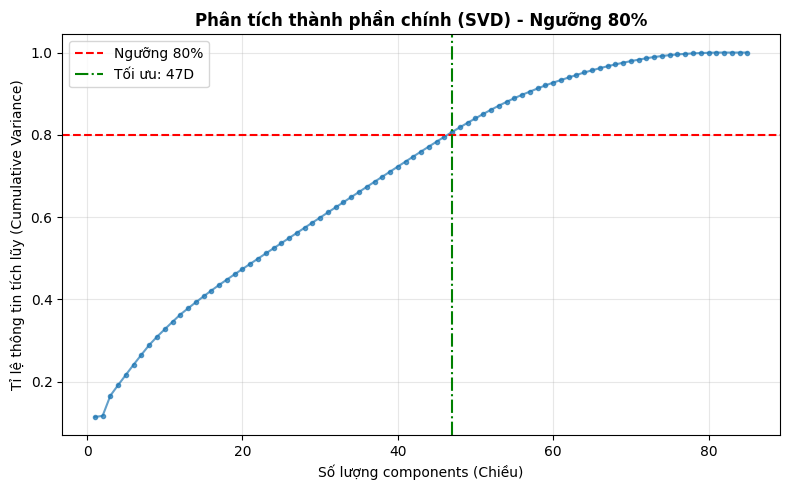

In [9]:
# Thử với test_size = 0.3
train_size_73 = split_indices[0.7]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=int(train_size_73), shuffle=False
)
X_train_scaled, X_test_scaled = preprocess_data(X_train, X_test)
n_components_80 = get_optimal_svd_components(X_train_scaled=X_train_scaled, target_variance=0.8, show_plot=True)

*Tìm k tối ưu (trên sample)*

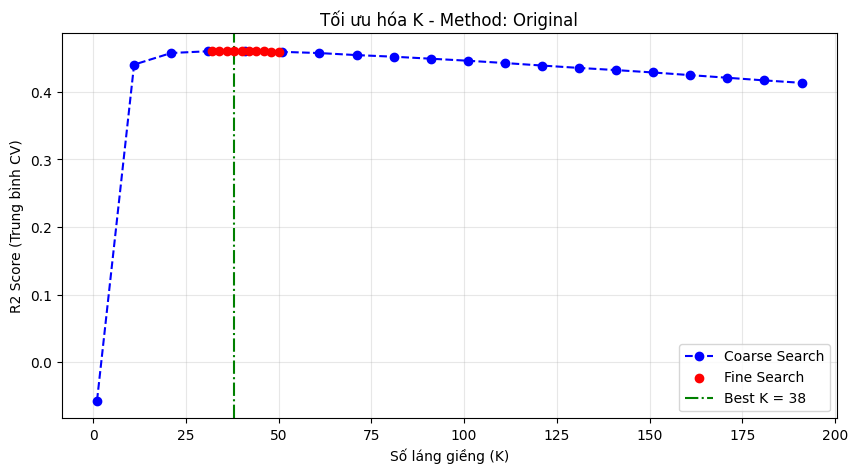

K tốt nhất cho bộ dữ liệu: 38


In [10]:
def find_best_k(X_train, y_train, method='Original', sample_size=20000, n_splits=5, random_state=42, show_plot=True):
    actual_sample_size = min(sample_size, len(X_train))
    
    if isinstance(X_train, pd.DataFrame):
        X_samp = X_train.iloc[-actual_sample_size:]
        y_samp = y_train.iloc[-actual_sample_size:] if hasattr(y_train, 'iloc') else y_train[-actual_sample_size:]
    else:
        X_samp = X_train[-actual_sample_size:]
        y_samp = y_train[-actual_sample_size:]

    if hasattr(X_samp, 'reset_index'): X_samp = X_samp.reset_index(drop=True)
    if hasattr(y_samp, 'reset_index'): y_samp = y_samp.reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=False)

    def evaluate_k_manual_cv(k_list, X_data, y_data, kf_splitter):
        k_scores = {k: [] for k in k_list}
        y_arr = y_data.values if hasattr(y_data, 'values') else np.array(y_data)

        for train_idx, val_idx in kf_splitter.split(X_data):
            if isinstance(X_data, pd.DataFrame):
                X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
            else:
                X_tr, X_val = X_data[train_idx], X_data[val_idx]

            y_tr, y_val = y_arr[train_idx], y_arr[val_idx]
            X_tr_scaled, X_val_scaled = preprocess_data(X_tr, X_val)

            if method.upper() == 'PCA':
                reducer = PCA(n_components=0.8, random_state=random_state)
                X_tr_final = reducer.fit_transform(X_tr_scaled)
                X_val_final = reducer.transform(X_val_scaled)
                
            elif method.upper() == 'SVD':
                dynamic_components = get_optimal_svd_components(
                    X_tr_scaled, target_variance=0.8, random_state=random_state, show_plot=False
                )
                reducer = TruncatedSVD(n_components=dynamic_components, random_state=random_state)
                X_tr_final = reducer.fit_transform(X_tr_scaled)
                X_val_final = reducer.transform(X_val_scaled)
                
            else:
                X_tr_final, X_val_final = X_tr_scaled, X_val_scaled

            
            for k in k_list:
                knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
                knn.fit(X_tr_final, y_tr)
                k_scores[k].append(knn.score(X_val_final, y_val))
                
        mean_cv_scores = [np.mean(k_scores[k]) for k in k_list]
        return mean_cv_scores

    # Tìm trên khoảng rộng
    k_values_coarse = range(1, 201, 10) 
    cv_scores_coarse = evaluate_k_manual_cv(k_values_coarse, X_samp, y_samp, kf)
    best_k_coarse = int(k_values_coarse[np.argmax(cv_scores_coarse)])

    # Fine Search 
    k_values_fine = range(max(1, best_k_coarse - 9), best_k_coarse + 10, 2)
    cv_scores_fine = evaluate_k_manual_cv(k_values_fine, X_samp, y_samp, kf)
    best_k_final = int(k_values_fine[np.argmax(cv_scores_fine)])

    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.plot(k_values_coarse, cv_scores_coarse, marker='o', linestyle='--', color='b', label='Coarse Search')
        plt.scatter(k_values_fine, cv_scores_fine, color='r', zorder=5, label='Fine Search')
        plt.axvline(x=best_k_final, color='g', linestyle='-.', label=f'Best K = {best_k_final}')
        plt.title(f'Tối ưu hóa K - Method: {method}')
        plt.xlabel('Số láng giềng (K)')
        plt.ylabel('R2 Score (Trung bình CV)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return best_k_final

train_size_73 = split_indices[0.7] 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=int(train_size_73), shuffle=False)

best_k_73 = find_best_k(X_train, y_train, method='Original', sample_size=20000, n_splits=5, random_state=42, show_plot=True)
print("K tốt nhất cho bộ dữ liệu:", best_k_73)

*KNN với với kiểu dữ liệu và test size khác nhau*

In [11]:
def run_knn_experiment_dynamic(X_data, y_data, method='Original'):
    results = []
    for split, train_size in split_indices.items():
        split_label = f"{int(split*10)}:{int(10 - split*10)}"
        X_train, X_test, y_train, y_test = train_test_split(
            X_data, y_data, train_size=int(train_size), shuffle=False
        )

        # 2. Tìm K tối ưu 
        best_k = find_best_k(X_train, y_train, method=method, show_plot=False)

        # 3. Chuẩn hóa
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        # 4. Giảm chiều
        if method.upper() == 'ORIGINAL':
            X_train_final, X_test_final = X_train_combined, X_test_combined
            data_type_name = 'Original'

        elif method.upper() == 'PCA':
            reducer = PCA(n_components=0.8, random_state=42)
            #reducer = PCA(n_components=0.8, svd_solver='full', random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = 'PCA'

        elif method.upper() == 'SVD':
            dynamic_components = get_optimal_svd_components(
                X_train_combined, target_variance=0.8,
                random_state=42, show_plot=False
            )
            reducer = TruncatedSVD(n_components=dynamic_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'TruncatedSVD ({dynamic_components}D)'

        else:
            raise ValueError("method chỉ hỗ trợ 'Original', 'PCA' hoặc 'SVD'")


        # 5. Model
        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        model = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
        model.fit(X_train_final, y_train_arr)
        
        y_train_pred = model.predict(X_train_final)
        y_test_pred  = model.predict(X_test_final)

        # 6. Đánh giá
        train_r2  = r2_score(y_train, y_train_pred)
        test_r2   = r2_score(y_test, y_test_pred)
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae  = mean_absolute_error(y_test, y_test_pred)
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse  = mean_squared_error(y_test, y_test_pred)

        results.append({
            'Data Type':          data_type_name,
            'Split (Train:Test)': split_label,
            'Best K':             best_k,
            'Train R2':           train_r2,
            'Test R2':            test_r2,
            'Gap R2':             train_r2 - test_r2,
            'Train MAE':          train_mae,
            'Test MAE':           test_mae,
            'Train MSE':          train_mse,
            'Test MSE':           test_mse,

            'Model Object':       model,
            'X_train_raw':        X_train, 
            'X_test_raw':         X_test,  
            'y_test_actual':      y_test,
            'y_test_pred':        y_test_pred,
            'y_train_actual':     y_train,
            'y_train_pred':       y_train_pred
        })

    return results

In [12]:
res_orig = run_knn_experiment_dynamic(X, y, method='Original')
res_pca  = run_knn_experiment_dynamic(X, y, method='PCA')
res_svd  = run_knn_experiment_dynamic(X, y, method='SVD')

all_results = res_orig + res_pca + res_svd

metrics_keys = ['Data Type', 'Split (Train:Test)', 'Best K', 'Train R2', 'Test R2', 'Gap R2', 'Train MAE', 'Test MAE', 'Train MSE', 'Test MSE']
df_display = pd.DataFrame([{k: d[k] for k in metrics_keys} for d in all_results])

display(df_display.round(4))

,Data Type,Split (Train:Test),Best K,Train R2,Test R2,Gap R2,Train MAE,Test MAE,Train MSE,Test MSE
0,Original,8:2,30,0.5316,0.5052,0.0264,4.2804,4.3983,28.2165,29.7919
1,Original,7:3,38,0.5235,0.5029,0.0206,4.3143,4.4214,28.6681,30.0160
2,Original,6:4,34,0.5236,0.4992,0.0244,4.3111,4.4385,28.6165,30.2869
3,PCA,8:2,32,0.5174,0.4930,0.0244,4.3437,4.4521,29.0733,30.5267
4,PCA,7:3,38,0.5122,0.4909,0.0213,4.3634,4.4738,29.3478,30.7445
5,PCA,6:4,34,0.5127,0.4878,0.0249,4.3564,4.4882,29.2720,30.9757
6,TruncatedSVD (47D),8:2,40,0.5121,0.4938,0.0183,4.3691,4.4484,29.3896,30.4805
7,TruncatedSVD (47D),7:3,38,0.5117,0.4900,0.0217,4.3661,4.4767,29.3814,30.7980
8,TruncatedSVD (47D),6:4,36,0.5108,0.4874,0.0234,4.3654,4.4889,29.3863,30.9996


In [13]:
output = 'output_charts'
os.makedirs(output, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(output, name), dpi=150, bbox_inches='tight')

df_results = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ('Model Object','X_train_raw','X_test_raw',
                  'y_test_actual','y_test_pred','y_train_actual','y_train_pred')}
    for r in all_results
])

SPLITS   = ['8:2', '7:3', '6:4']
METHODS  = df_results['Data Type'].unique().tolist()
PALETTE  = {m: c for m, c in zip(METHODS, ['dodgerblue', 'darkorange', 'forestgreen'])}

# print("Methods:", METHODS)
# print("Splits :", SPLITS)
# display(df_results[['Data Type','Split (Train:Test)','Best K','Train R2','Test R2','Gap R2','Train MAE','Test MAE']])

### So sánh kết quả

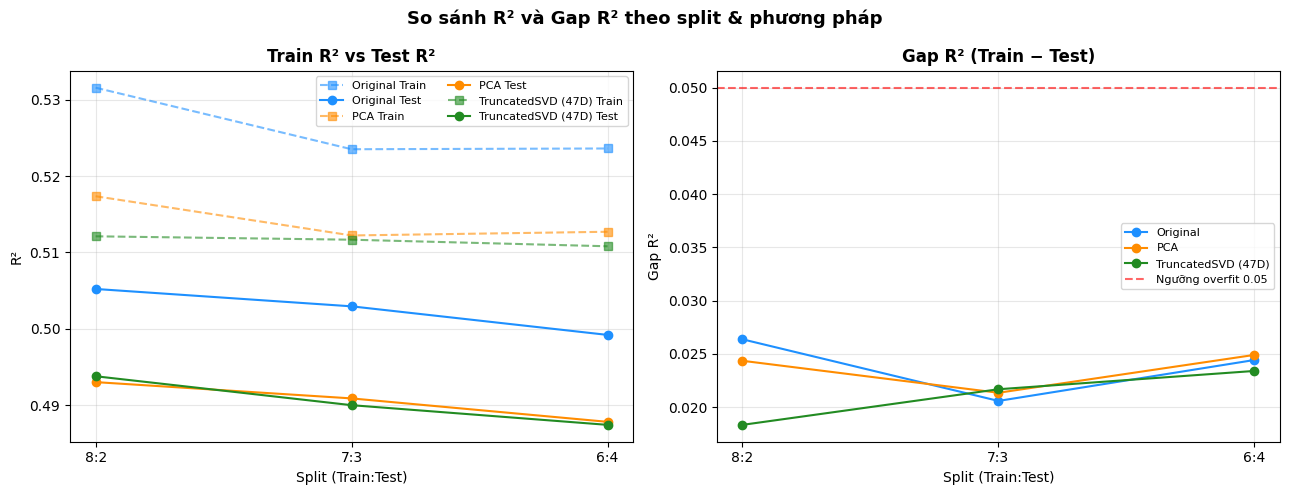

In [14]:
# Train R² / Test R² / Gap R²
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for method in METHODS:
    sub = (df_results[df_results['Data Type'] == method]
           .set_index('Split (Train:Test)').reindex(SPLITS))
    color = PALETTE[method]
    axes[0].plot(SPLITS, sub['Train R2'], marker='s', linestyle='--', color=color, alpha=0.6, label=f'{method} Train')
    axes[0].plot(SPLITS, sub['Test R2'],  marker='o', color=color, label=f'{method} Test')
    axes[1].plot(SPLITS, sub['Gap R2'],   marker='o', color=color, label=method)

axes[0].set_title('Train R² vs Test R²', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0.05, color='red', linestyle='--', alpha=0.6, label='Ngưỡng overfit 0.05')
axes[1].set_title('Gap R² (Train − Test)', fontweight='bold')
axes[1].set_ylabel('Gap R²')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('Split (Train:Test)')

plt.suptitle('So sánh R² và Gap R² theo split & phương pháp', fontweight='bold', fontsize=13)
plt.tight_layout()
savefig('1a_part1_r2_gap.png')
plt.show()

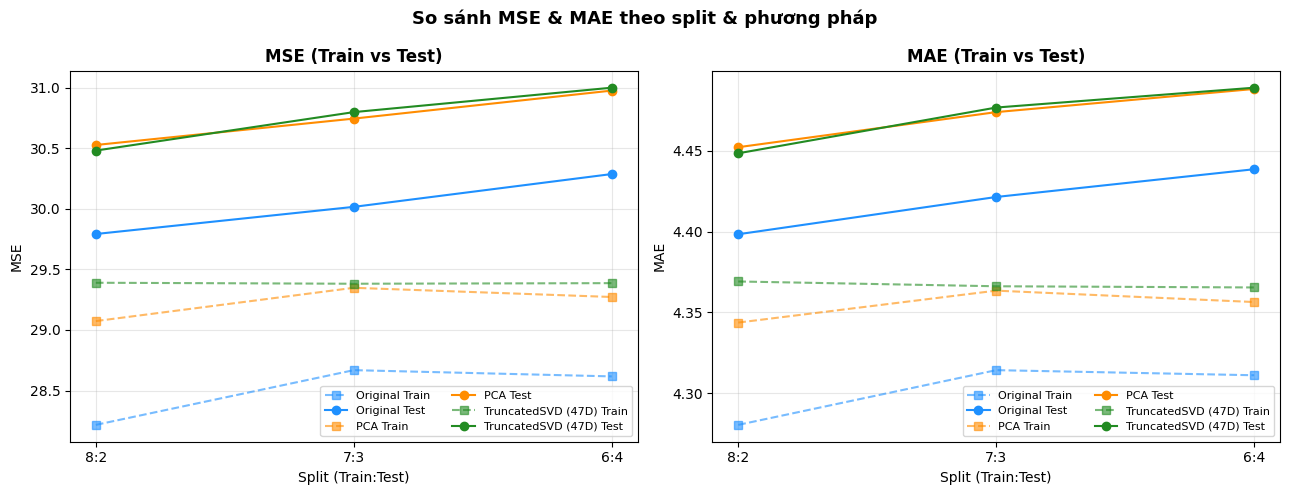

In [15]:
# MSE & MAE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for method in METHODS:
    sub = (df_results[df_results['Data Type'] == method]
           .set_index('Split (Train:Test)').reindex(SPLITS))
    color = PALETTE[method]
    axes[0].plot(SPLITS, sub['Train MSE'], marker='s', linestyle='--', color=color, alpha=0.6, label=f'{method} Train')
    axes[0].plot(SPLITS, sub['Test MSE'],  marker='o', color=color, label=f'{method} Test')
    axes[1].plot(SPLITS, sub['Train MAE'], marker='s', linestyle='--', color=color, alpha=0.6, label=f'{method} Train')
    axes[1].plot(SPLITS, sub['Test MAE'],  marker='o', color=color, label=f'{method} Test')

axes[0].set_title('MSE (Train vs Test)', fontweight='bold')
axes[0].set_ylabel('MSE')
axes[1].set_title('MAE (Train vs Test)', fontweight='bold')
axes[1].set_ylabel('MAE')

for ax in axes:
    ax.set_xlabel('Split (Train:Test)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('So sánh MSE & MAE theo split & phương pháp', fontweight='bold', fontsize=13)
plt.tight_layout()
savefig('1a_part2_mse_mae.png')
plt.show()

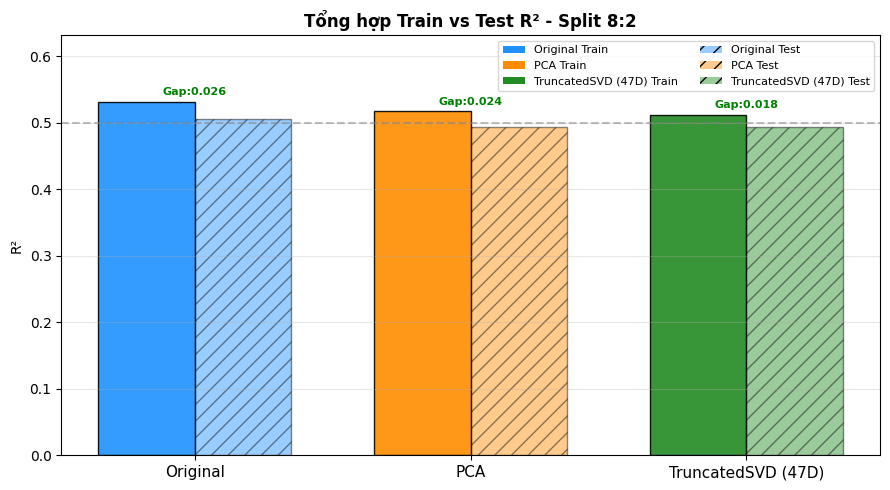

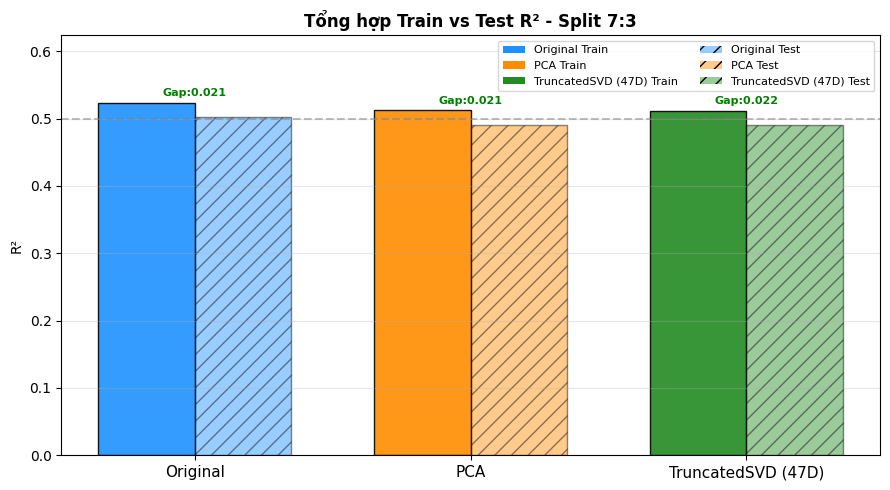

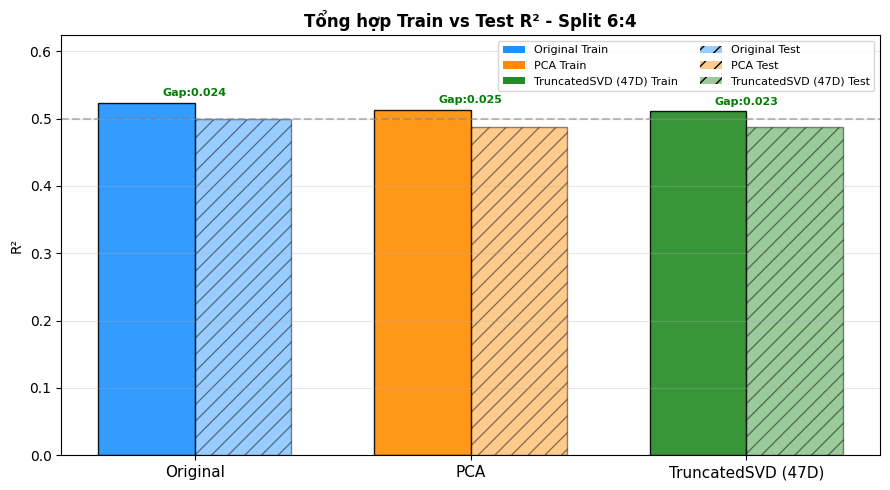

In [16]:
# Train vs Test R² theo nhóm

for split_label in SPLITS:
    sub = df_results[df_results['Split (Train:Test)'] == split_label].copy()

    x     = np.arange(len(sub))
    width = 0.35
    colors = [PALETTE.get(m, 'lightgray') for m in sub['Data Type']]

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (_, row) in enumerate(sub.iterrows()):
        c = PALETTE.get(row['Data Type'], 'lightgray')
        b1 = ax.bar(i - width/2, row['Train R2'], width, color=c, alpha=0.9,
                    edgecolor='black', label=f"{row['Data Type']} Train" if split_label == '8:2' else '')
        b2 = ax.bar(i + width/2, row['Test R2'],  width, color=c, alpha=0.45,
                    edgecolor='black', hatch='//',
                    label=f"{row['Data Type']} Test" if split_label == '8:2' else '')
        gap = row['Gap R2']
        y_pos = max(row['Train R2'], row['Test R2']) + 0.01
        ax.text(i, y_pos, f"Gap:{gap:.3f}",
                ha='center', fontsize=8,
                color='red' if gap > 0.05 else 'green', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(sub['Data Type'], fontsize=11)
    ax.set_ylabel('R²')
    ax.set_ylim(0, max(sub['Train R2'].max(), sub['Test R2'].max()) + 0.1)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='R²=0.5 baseline')
    ax.set_title(f'Tổng hợp Train vs Test R² - Split {split_label}', fontweight='bold')

    # Legend 
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=PALETTE[m], label=f'{m} Train') for m in METHODS] + \
                      [Patch(facecolor=PALETTE[m], alpha=0.45, hatch='//', label=f'{m} Test') for m in METHODS]
    ax.legend(handles=legend_elements, fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    savefig(f'1e_grouped_bar_{split_label.replace(":", "")}.png')
    plt.show()

### Kiểm tra overfit

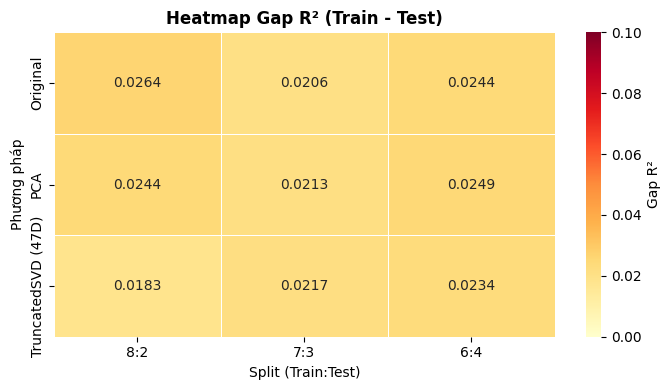

In [17]:
# Heatmap Gap R²

pivot_gap = df_results.pivot(
    index='Data Type', columns='Split (Train:Test)', values='Gap R2'
)[SPLITS]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_gap, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Gap R²'},
            vmin=0, vmax=0.1)
ax.set_title('Heatmap Gap R² (Train - Test)', fontweight='bold')
ax.set_xlabel('Split (Train:Test)')
ax.set_ylabel('Phương pháp')
plt.tight_layout()
savefig('1b_heatmap_gap_r2.png')
plt.show()

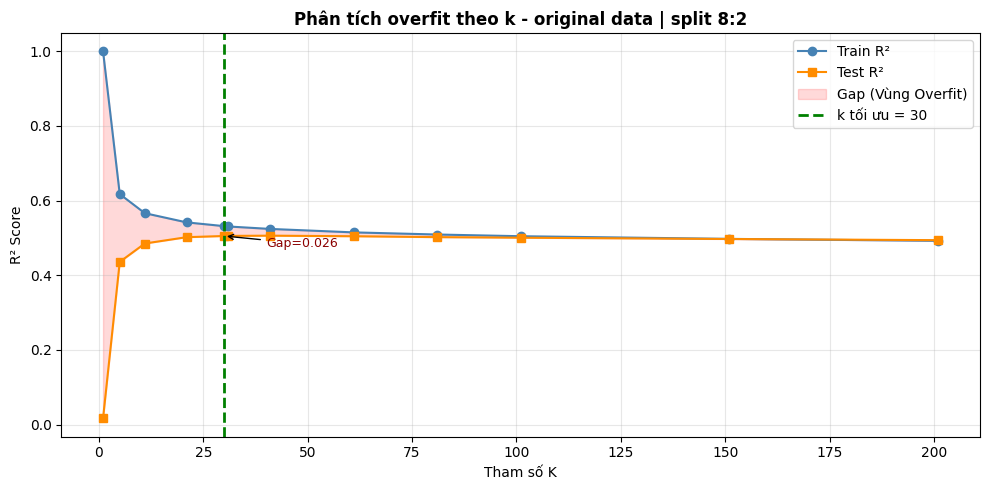

Split 8:2 | k=30 | Train R²=0.5316 | Test R²=0.5052 | Gap=0.0264
Kết luận: Gap nhỏ, mô hình không bị overfit. 



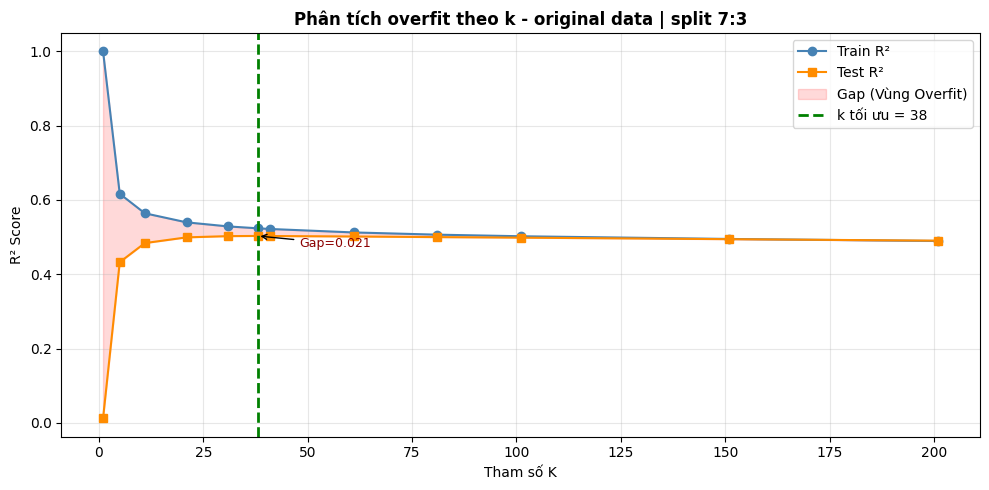

Split 7:3 | k=38 | Train R²=0.5235 | Test R²=0.5029 | Gap=0.0206
Kết luận: Gap nhỏ, mô hình không bị overfit. 



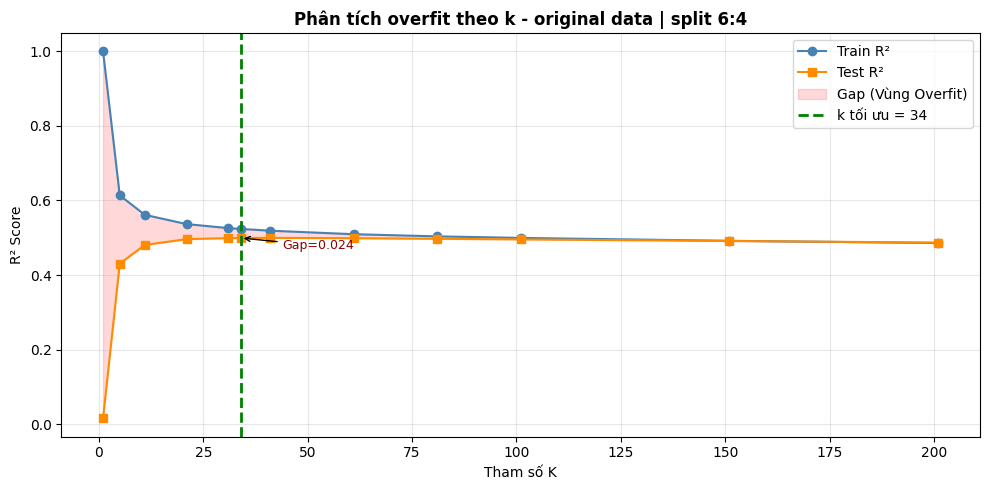

Split 6:4 | k=34 | Train R²=0.5236 | Test R²=0.4992 | Gap=0.0244
Kết luận: Gap nhỏ, mô hình không bị overfit. 



In [18]:
# K vs R² (Phân tích Overfit theo K)
# Dùng dữ liệu Original
from sklearn.model_selection import train_test_split as tts

k_range_plot = [1, 5, 11, 21, 31, 41, 61, 81, 101, 151, 201]

for split_label in SPLITS:
    test_size = {'8:2': 0.2, '7:3': 0.3, '6:4': 0.4}[split_label]

    res = next(r for r in all_results
               if r['Data Type'] == 'Original' and r['Split (Train:Test)'] == split_label)
    best_k = res['Best K']

    
    X_tr_raw = res['X_train_raw']
    X_te_raw = res['X_test_raw']
    y_tr_arr = (res['y_train_actual'].values
                if hasattr(res['y_train_actual'], 'values')
                else np.array(res['y_train_actual']))
    y_te_arr = (res['y_test_actual'].values
                if hasattr(res['y_test_actual'], 'values')
                else np.array(res['y_test_actual']))

    # Scale lại 
    X_tr_f, X_te_f = preprocess_data(X_tr_raw, X_te_raw)

    # Thêm best_k vào k_range nếu chưa có
    k_range = sorted(set(k_range_plot + [best_k]))

    train_r2_list, test_r2_list = [], []
    for k in k_range:
        m = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
        m.fit(X_tr_f, y_tr_arr)
        train_r2_list.append(r2_score(y_tr_arr, m.predict(X_tr_f)))
        test_r2_list.append(r2_score(y_te_arr,  m.predict(X_te_f)))

    gap_list = [tr - te for tr, te in zip(train_r2_list, test_r2_list)]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(k_range, train_r2_list, marker='o', color='steelblue', label='Train R²')
    ax.plot(k_range, test_r2_list,  marker='s', color='darkorange', label='Test R²')
    ax.fill_between(k_range, train_r2_list, test_r2_list,
                    alpha=0.15, color='red', label='Gap (Vùng Overfit)')
    ax.axvline(x=best_k, color='green', linestyle='--', linewidth=2,
               label=f'k tối ưu = {best_k}')

    # Gap tại best_k
    idx_best = k_range.index(best_k)
    gap_at_best = gap_list[idx_best]
    ax.annotate(f'Gap={gap_at_best:.3f}',
                xy=(best_k, test_r2_list[idx_best]),
                xytext=(best_k + 10, test_r2_list[idx_best] - 0.03),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, color='darkred')

    ax.set_xlabel('Tham số K')
    ax.set_ylabel('R² Score')
    ax.set_title(f'Phân tích overfit theo k - original data | split {split_label}',
                 fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    savefig(f'1c_k_overfit_{split_label.replace(":", "")}.png')
    plt.show()
    print(f"Split {split_label} | k={best_k} | Train R²={train_r2_list[idx_best]:.4f} | "
          f"Test R²={test_r2_list[idx_best]:.4f} | Gap={gap_at_best:.4f}")
    verdict = "Gap nhỏ, mô hình không bị overfit." if gap_at_best < 0.05 else "Gap còn lớn, có dấu hiệu overfit."
    print("Kết luận:", verdict, "\n")

### Regularization

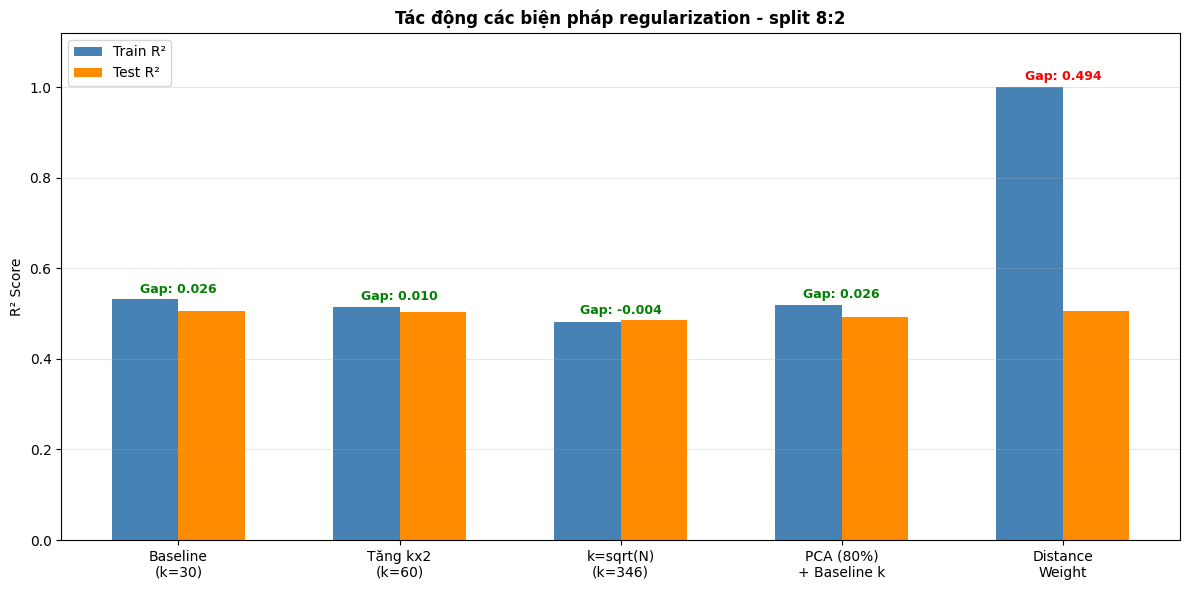

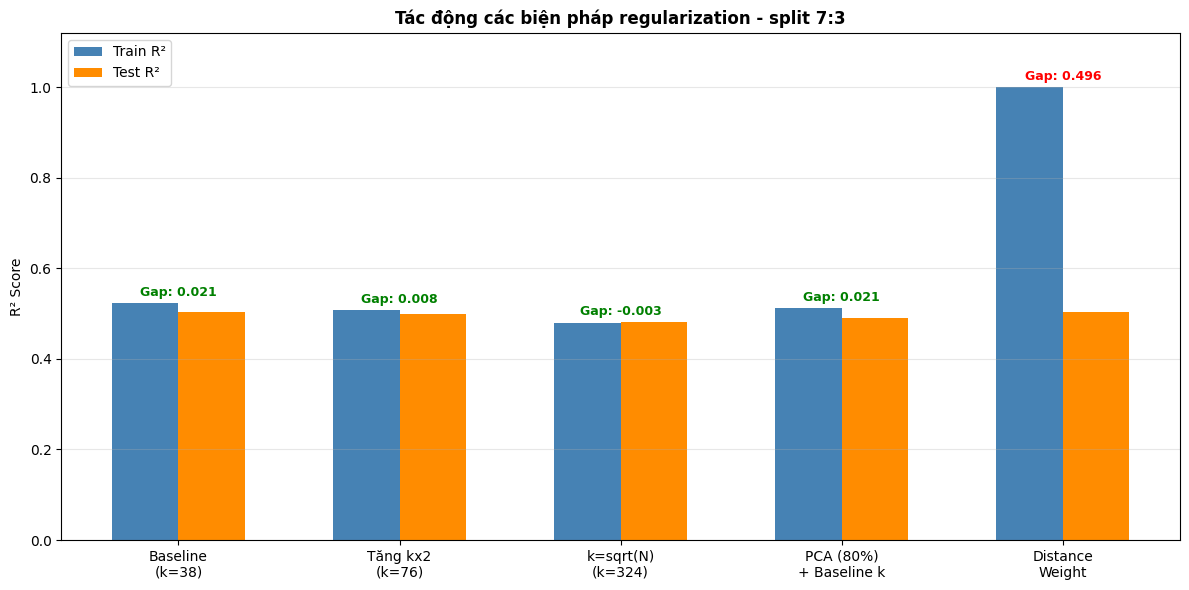

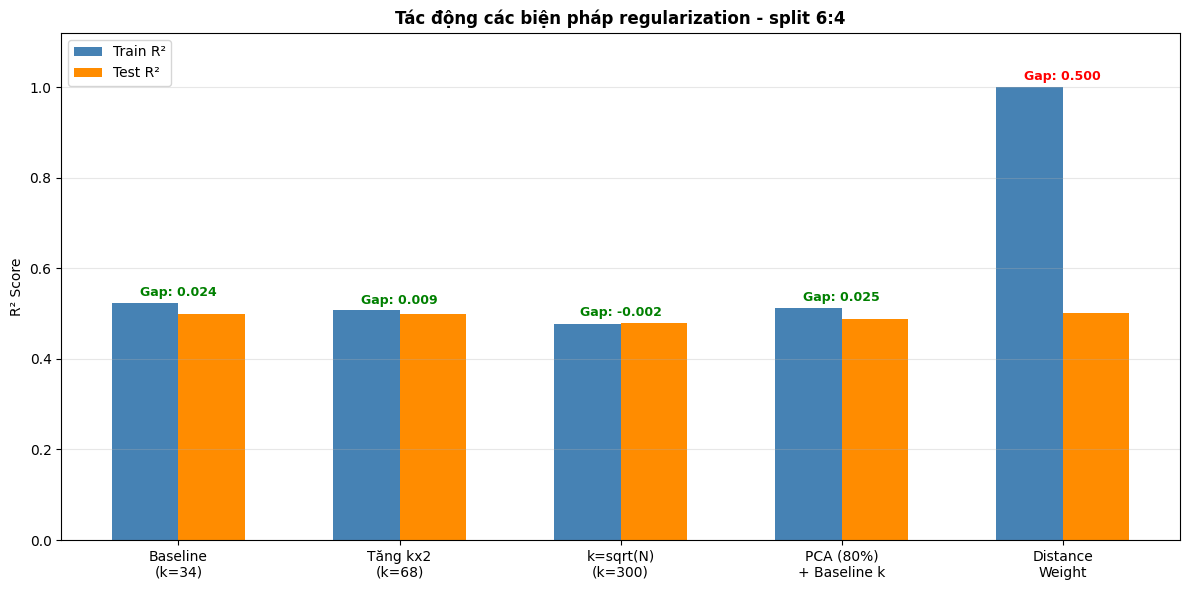

In [19]:
# Tác động các biện pháp regularization

for split_label in SPLITS:
    test_size = {'8:2': 0.2, '7:3': 0.3, '6:4': 0.4}[split_label]

    res = next(r for r in all_results
               if r['Data Type'] == 'Original' and r['Split (Train:Test)'] == split_label)
    best_k = res['Best K']

    X_tr_raw = res['X_train_raw']
    X_te_raw = res['X_test_raw']
    y_tr_arr = (res['y_train_actual'].values
                if hasattr(res['y_train_actual'], 'values')
                else np.array(res['y_train_actual']))
    y_te_arr = (res['y_test_actual'].values
                if hasattr(res['y_test_actual'], 'values')
                else np.array(res['y_test_actual']))

    X_tr_f, X_te_f = preprocess_data(X_tr_raw, X_te_raw)

    N          = len(X_tr_f)
    k_sqrt_N   = int(np.sqrt(N))

    # PCA 
    pca_obj    = PCA(n_components=0.8, random_state=42)
    X_tr_pca   = pca_obj.fit_transform(X_tr_f)
    X_te_pca   = pca_obj.transform(X_te_f)

    configs = [
        {'name': f'Baseline\n(k={best_k})', 'k': best_k, 'weights': 'uniform', 'Xtr': X_tr_f, 'Xte': X_te_f},
        {'name': f'Tăng kx2\n(k={best_k*2})', 'k': best_k*2, 'weights': 'uniform', 'Xtr': X_tr_f, 'Xte': X_te_f},
        {'name': f'k=sqrt(N)\n(k={k_sqrt_N})', 'k': k_sqrt_N, 'weights': 'uniform', 'Xtr': X_tr_f, 'Xte': X_te_f},
        {'name': 'PCA (80%)\n+ Baseline k', 'k': best_k, 'weights': 'uniform', 'Xtr': X_tr_pca, 'Xte': X_te_pca},
        {'name': 'Distance\nWeight', 'k': best_k, 'weights': 'distance', 'Xtr': X_tr_f, 'Xte': X_te_f},
    ]

    reg_results = []
    for cfg in configs:
        m = KNeighborsRegressor(n_neighbors=cfg['k'], weights=cfg['weights'], n_jobs=-1)
        m.fit(cfg['Xtr'], y_tr_arr)
        tr_r2 = r2_score(y_tr_arr, m.predict(cfg['Xtr']))
        te_r2 = r2_score(y_te_arr, m.predict(cfg['Xte']))
        reg_results.append({'name': cfg['name'], 'Train R²': tr_r2, 'Test R²': te_r2,
                            'Gap': tr_r2 - te_r2})

    df_reg = pd.DataFrame(reg_results)
    x      = np.arange(len(df_reg))
    width  = 0.3

    fig, ax = plt.subplots(figsize=(12, 6))
    bars_tr = ax.bar(x - width/2, df_reg['Train R²'], width, label='Train R²', color='steelblue')
    bars_te = ax.bar(x + width/2, df_reg['Test R²'],  width, label='Test R²',  color='darkorange')

    for i, row in df_reg.iterrows():
        y_pos = max(row['Train R²'], row['Test R²']) + 0.015
        color_txt = 'red' if row['Gap'] > 0.05 else 'green'
        ax.text(i, y_pos, f"Gap: {row['Gap']:.3f}",
                ha='center', fontsize=9, color=color_txt, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(df_reg['name'], fontsize=10)
    ax.set_ylabel('R² Score')
    ax.set_ylim(0, max(df_reg['Train R²'].max(), df_reg['Test R²'].max()) + 0.12)
    ax.set_title(f'Tác động các biện pháp regularization - split {split_label}',
                 fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    savefig(f'1d_regularization_{split_label.replace(":", "")}.png')
    plt.show()

### 1.4 (b) Phân tích phần dư

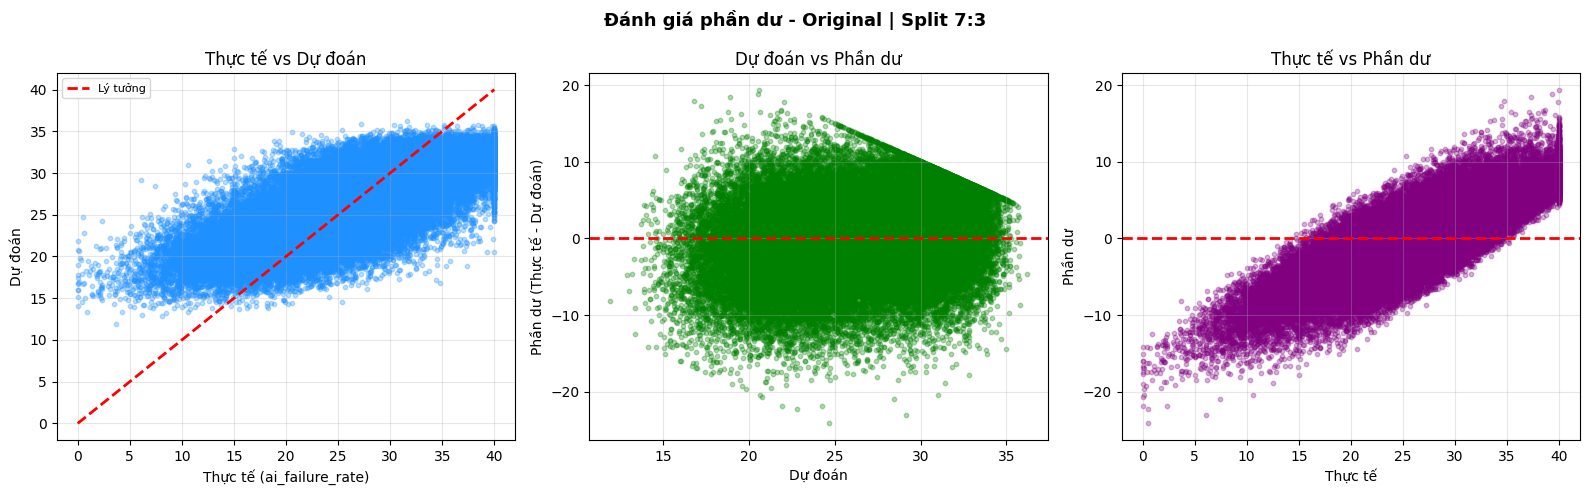

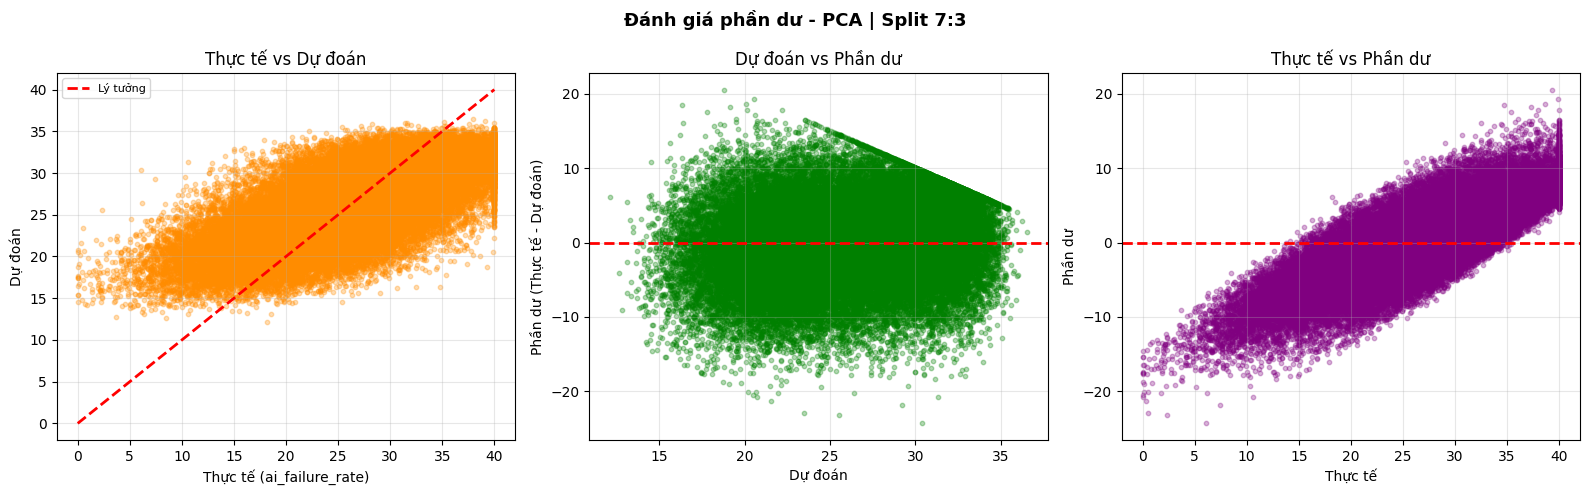

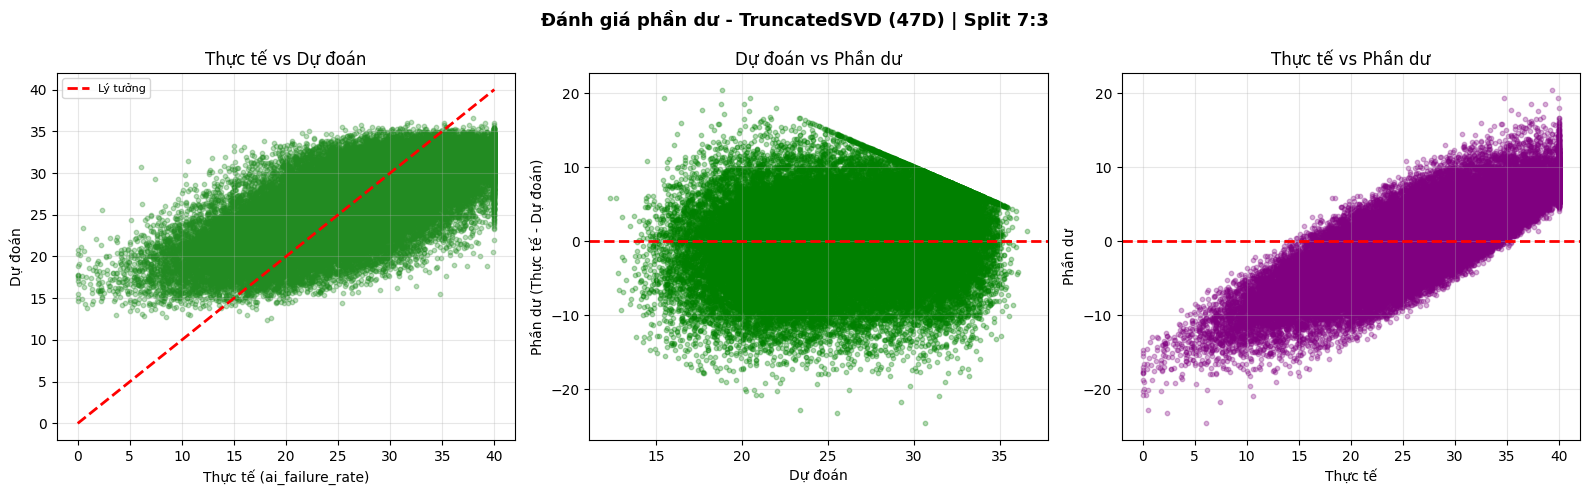

In [20]:
# Actual vs Pred / Pred vs Res / Actual vs Res

for method in METHODS:
    res = next(r for r in all_results
               if r['Data Type'] == method and r['Split (Train:Test)'] == '7:3')
    ya   = (res['y_test_actual'].values if hasattr(res['y_test_actual'], 'values')
            else np.array(res['y_test_actual']))
    yp   = res['y_test_pred']
    resid = ya - yp

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Actual vs Pred
    axes[0].scatter(ya, yp, alpha=0.3, s=10, color=PALETTE.get(method, 'lightgray'))
    mn, mx = ya.min(), ya.max()
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Lý tưởng')
    axes[0].set_title('Thực tế vs Dự đoán')
    axes[0].set_xlabel('Thực tế (ai_failure_rate)')
    axes[0].set_ylabel('Dự đoán')
    axes[0].legend(fontsize=8)

    # Pred vs Residual
    axes[1].scatter(yp, resid, alpha=0.3, s=10, color='green')
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Dự đoán vs Phần dư')
    axes[1].set_xlabel('Dự đoán')
    axes[1].set_ylabel('Phần dư (Thực tế - Dự đoán)')

    # Actual vs Residual
    axes[2].scatter(ya, resid, alpha=0.3, s=10, color='purple')
    axes[2].axhline(0, color='r', linestyle='--', lw=2)
    axes[2].set_title('Thực tế vs Phần dư')
    axes[2].set_xlabel('Thực tế')
    axes[2].set_ylabel('Phần dư')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Đánh giá phần dư - {method} | Split 7:3', fontweight='bold', fontsize=13)
    plt.tight_layout()
    savefig(f'2a_residual_scatter_{method.split()[0]}.png')
    plt.show()

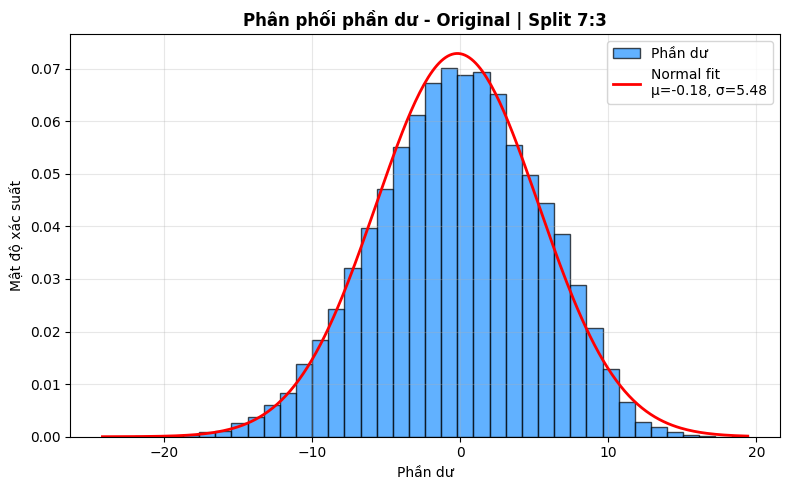

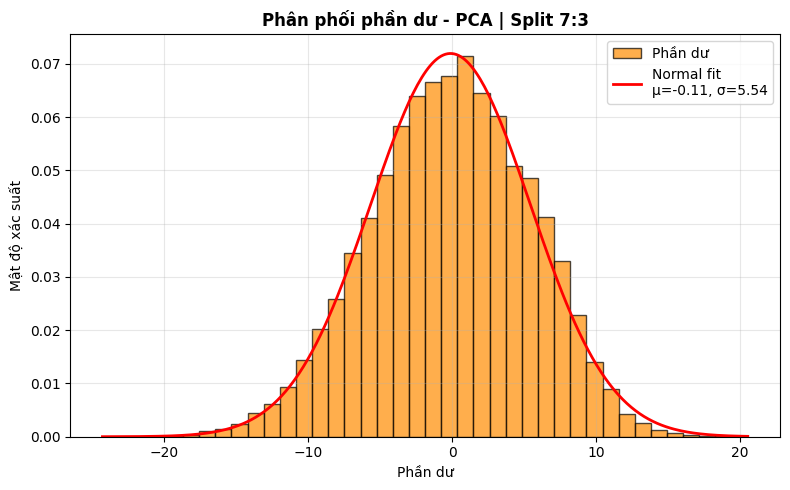

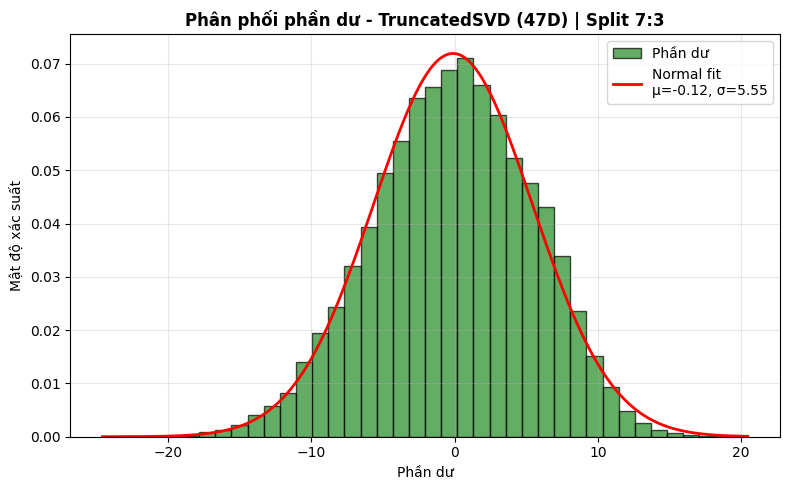

In [21]:
# Histogram phân phối phần dư

for method in METHODS:
    res = next(r for r in all_results
               if r['Data Type'] == method and r['Split (Train:Test)'] == '7:3')
    ya    = (res['y_test_actual'].values if hasattr(res['y_test_actual'], 'values')
             else np.array(res['y_test_actual']))
    resid = ya - res['y_test_pred']

    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Histogram
    ax.hist(resid, bins=40, color=PALETTE.get(method, '#888'),
            edgecolor='black', alpha=0.7, density=True, label='Phần dư')

    # Normal fit
    mu, sigma = resid.mean(), resid.std()
    x_plot = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(x_plot, stats.norm.pdf(x_plot, mu, sigma),
            'r-', lw=2, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')

    ax.set_title(f'Phân phối phần dư - {method} | Split 7:3', fontweight='bold')
    ax.set_xlabel('Phần dư')
    ax.set_ylabel('Mật độ xác suất')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    savefig(f'2b_residual_dist_{method.split()[0]}.png')
    plt.show()

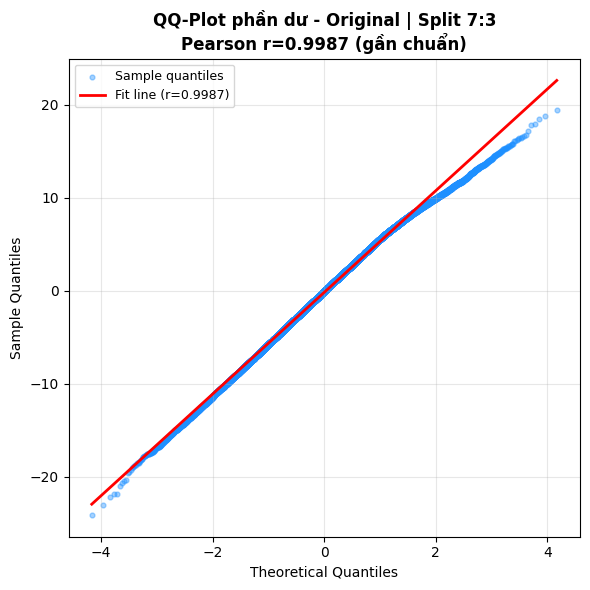

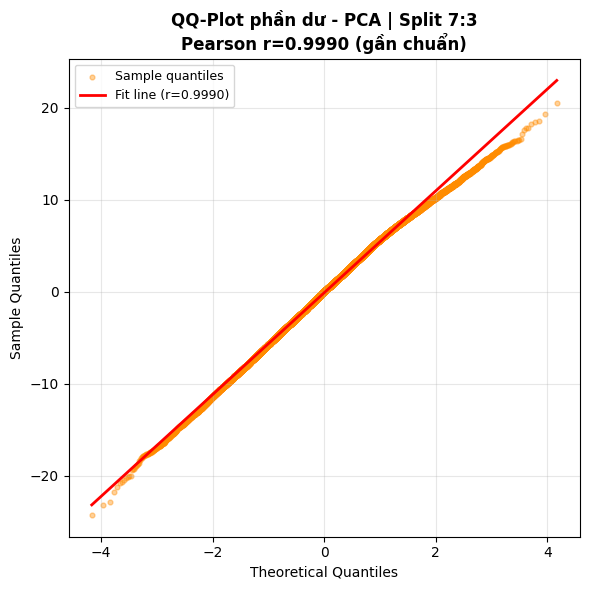

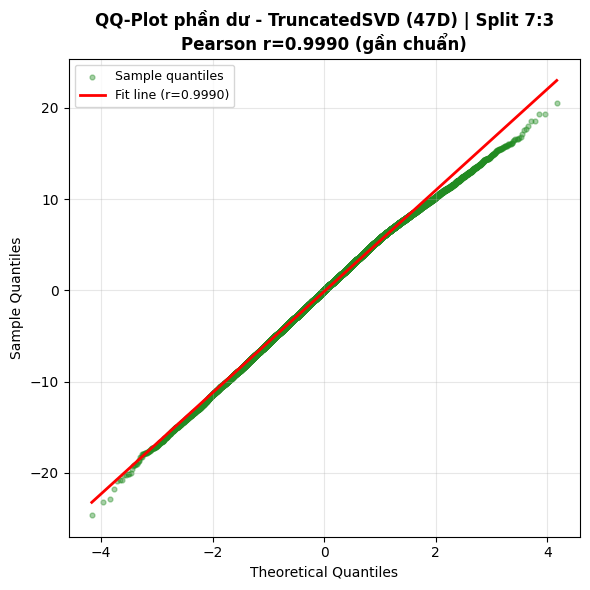

In [22]:
# QQ-Plot phần dư

for method in METHODS:
    res = next(r for r in all_results
               if r['Data Type'] == method and r['Split (Train:Test)'] == '7:3')
    ya    = (res['y_test_actual'].values if hasattr(res['y_test_actual'], 'values')
             else np.array(res['y_test_actual']))
    resid = ya - res['y_test_pred']

    fig, ax = plt.subplots(figsize=(6, 6))
    (osm, osr), (slope, intercept, r_val) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=12, color=PALETTE.get(method, '#lightgray'), label='Sample quantiles')
    ax.plot(np.array(osm), slope * np.array(osm) + intercept,
            'r-', lw=2, label=f'Fit line (r={r_val:.4f})')
    ax.set_title(f'QQ-Plot phần dư - {method} | Split 7:3\n'
                 f'Pearson r={r_val:.4f} '
                 f'({"gần chuẩn" if r_val > 0.99 else "lệch khỏi chuẩn"})',
                 fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    savefig(f'2c_qqplot_{method.split()[0]}.png')
    plt.show()

### Phần dư với biến đầu vào

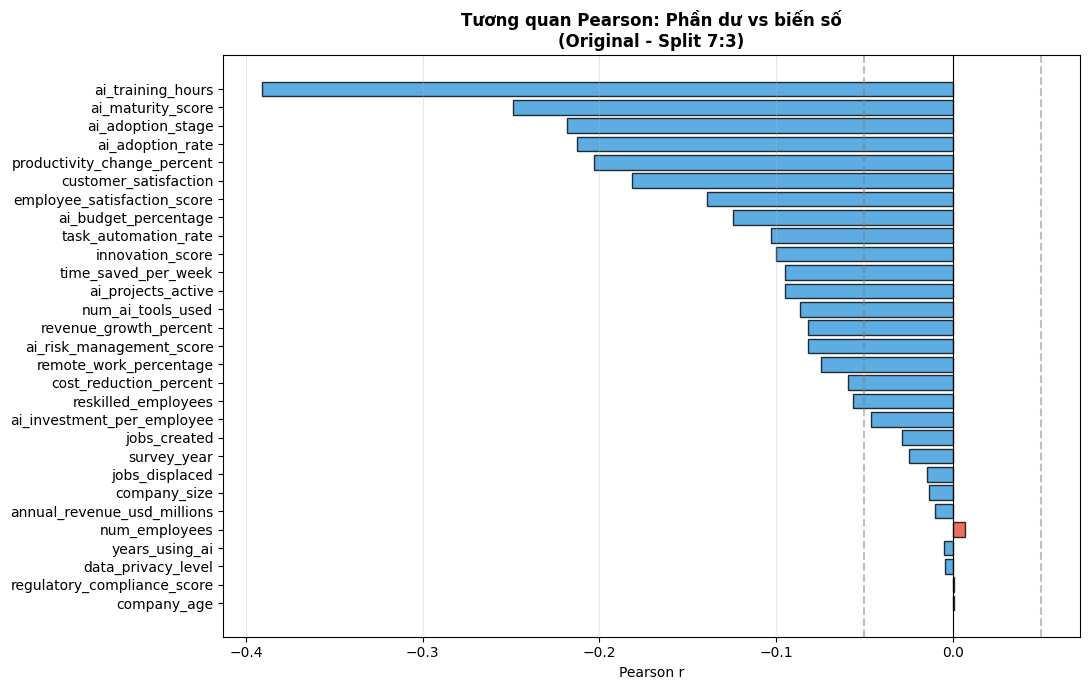

In [23]:
# Pearson correlation phần dư vs biến số

res_73    = next(r for r in all_results
                 if r['Data Type'] == 'Original' and r['Split (Train:Test)'] == '7:3')
X_test_raw = res_73['X_test_raw'].copy().reset_index(drop=True)
ya_73     = (res_73['y_test_actual'].values if hasattr(res_73['y_test_actual'], 'values')
             else np.array(res_73['y_test_actual']))
resid_73  = ya_73 - res_73['y_test_pred']

numeric_cols_avail = [c for c in NUMERIC_ORDINAL_COLS if c in X_test_raw.columns]

corr_vals = {col: stats.pearsonr(X_test_raw[col], resid_73)[0] for col in numeric_cols_avail}
corr_series = pd.Series(corr_vals).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_series.values]
ax.barh(corr_series.index[::-1], corr_series.values[::-1],
        color=colors_bar[::-1], edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.05, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-0.05, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Tương quan Pearson: Phần dư vs biến số\n(Original - Split 7:3)',
             fontweight='bold')
ax.set_xlabel('Pearson r')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
savefig('3a_corr_numeric_residual.png')
plt.show()

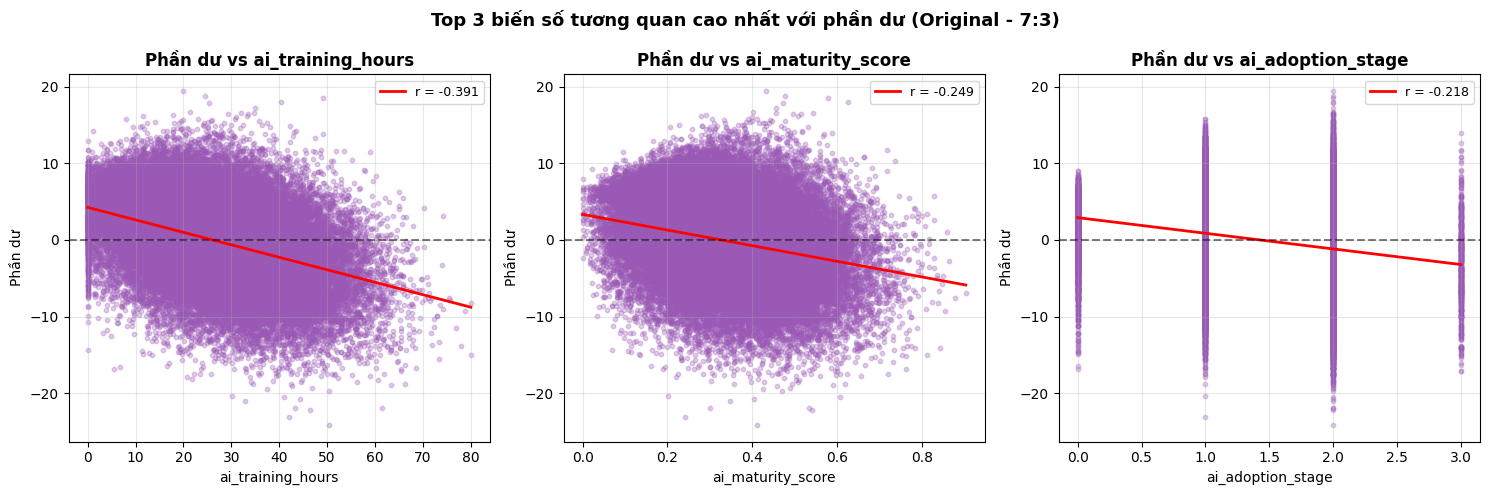

In [24]:
# Scatter top 3 biến vs phần dư

top3 = corr_series.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(top3):
    x_vals = X_test_raw[col].values
    axes[i].scatter(x_vals, resid_73, alpha=0.3, s=10, color='#9b59b6')
    m_fit, b_fit = np.polyfit(x_vals, resid_73, 1)
    xs = np.linspace(x_vals.min(), x_vals.max(), 200)
    axes[i].plot(xs, m_fit * xs + b_fit, 'r-', lw=2,
                 label=f'r = {corr_series[col]:.3f}')
    axes[i].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Phần dư vs {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Phần dư')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Top 3 biến số tương quan cao nhất với phần dư (Original - 7:3)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig('3b_top3_scatter_residual.png')
plt.show()

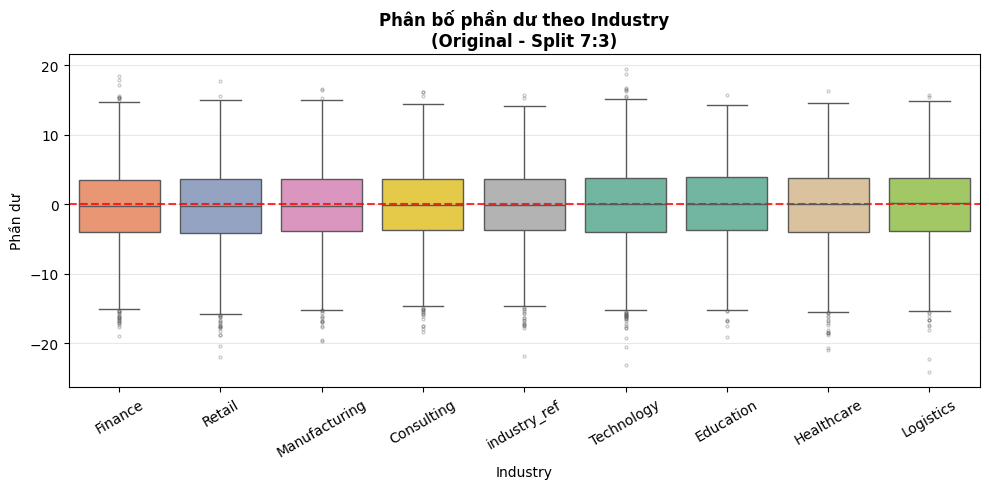

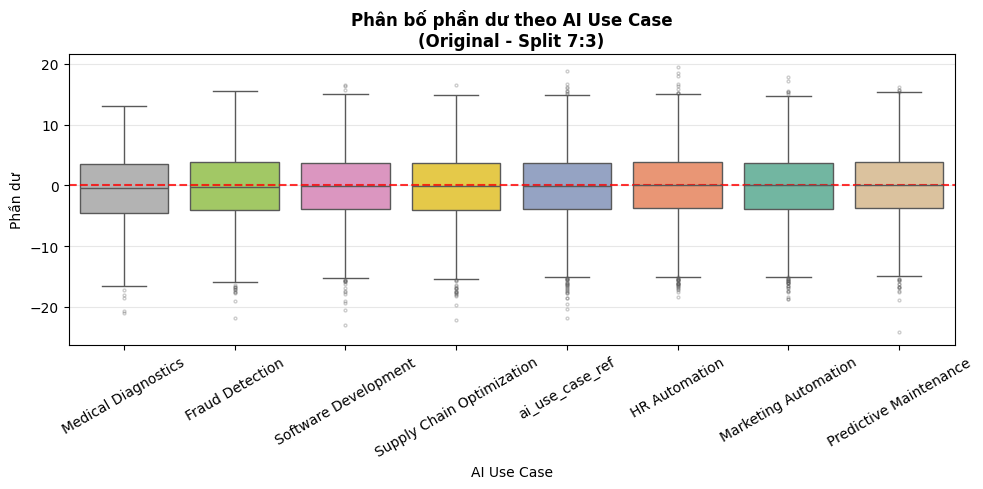

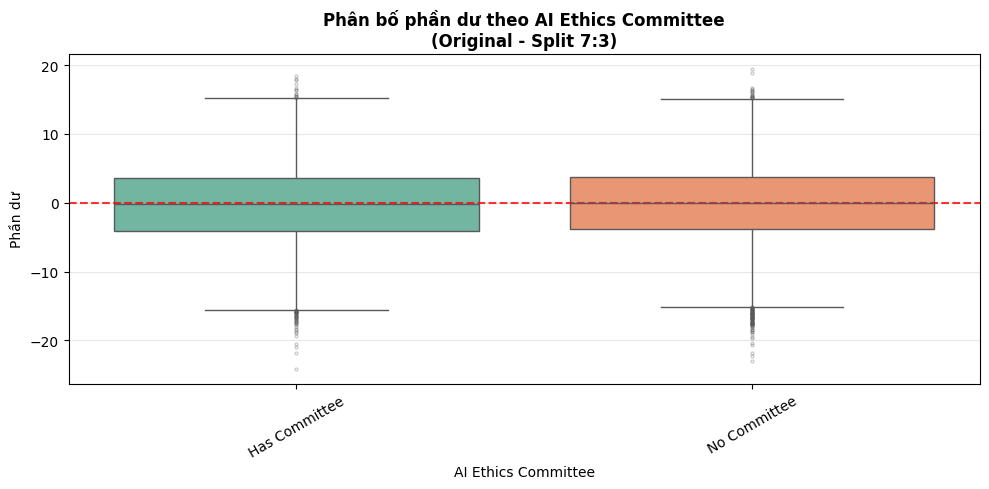

In [25]:
# Boxplot phần dư theo biến phân loại tiêu biểu
# Chọn 3 biến tiêu biểu: industry, ai_use_case, ai_ethics_committee

# Decode one-hot => label gốc
def decode_onehot(X_df, prefix):
    cols = [c for c in X_df.columns if c.startswith(prefix + '_')]
    if not cols:
        return None
    decoded = X_df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
    row_sum = X_df[cols].sum(axis=1)
    decoded[row_sum == 0] = f'{prefix}_ref'
    return decoded

industry_label  = decode_onehot(X_test_raw, 'industry')
use_case_label  = decode_onehot(X_test_raw, 'ai_use_case')
ethics_label    = X_test_raw['ai_ethics_committee'].map({0: 'No Committee', 1: 'Has Committee'})

chosen_cats = {
    'Industry': industry_label,
    'AI Use Case': use_case_label,
    'AI Ethics Committee': ethics_label,
}

for cat_name, cat_series in chosen_cats.items():
    if cat_series is None:
        continue
    df_plot = pd.DataFrame({'Category': cat_series.values, 'Residual': resid_73})
    order   = df_plot.groupby('Category')['Residual'].median().sort_values().index

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_plot, x='Category', y='Residual', order=order,
                ax=ax, palette='Set2', hue='Category', legend=False,
                flierprops=dict(marker='.', alpha=0.3, markersize=4))
    ax.axhline(0, color='red', linestyle='--', lw=1.5, alpha=0.8)
    ax.set_title(f'Phân bố phần dư theo {cat_name}\n(Original - Split 7:3)',
                 fontweight='bold')
    ax.set_xlabel(cat_name)
    ax.set_ylabel('Phần dư')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    savefig(f'3c_boxplot_{cat_name.lower().replace(" ","_")}.png')
    plt.show()
